## NEW parameter settings (tan-HYPERBOLICUS, kernel & z-trans)

See how changing GM.fitting with in paper used standard settings changes?!

- align ref: average with tan-HYPERBOLICUs!!  (CM generated in `averageGMs_01.ipynb`)
- normalize (z-score) (+ nans to 0s)
- kernel = 'normalized_angle' - Serio/Wang | 'cosine' (e.g. autism paper)/ 

--> fit for subjects in `fit_gradients_dParams.py`
--> group comparisons in `rep_groupDiffs_dParams.ipynb`

Notes:
- for kernel='normalized_angle'+ztransf - we now need again the cc-mask fltering, otherwise there is the "... affinity matrix no Infs/Nans"
 --> only for a few subjects... for the one where the error does not come up, +/- _ccfilter does not make any difference in the GMs!
-->> interestingly kernel='normalized_angle'& ztransf=False does not cause this problem
- & for kernel=None+ztransf it is enough to set cm[np.isna(cm)] = 0 



In [1]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt
import seaborn as sns

from utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

dataset ='dnumrisk' #'smile1'#
bids_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-{dataset}'
subList = [f'{int(sub):02d}' for sub in range(1, 67)]

target_folder = op.join(bids_folder,'derivatives','gradients.tryParams.36P')

In [ ]:
# parrellelizing running script (run via ipython in terminal)

import subprocess
from multiprocessing import Pool, cpu_count

# List your subject IDs (adjust as needed)
subjects = list(range(1, 67))  # e.g., subjects 1–20

# Optional: define fixed arguments
bids_folder = "/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk"
kernel = "normalized_angle"  # or "cosine", or None
ztransf = True
alignRef = "-tanH"

def run_subject(sub):
    subprocess.run(["python", "fit_gradients_dParams.py", str(sub),
                    "--kernel", kernel,
                    "--ztransf"]) # if ztransf 
    
n_cores = cpu_count() - 1  # leave one core free

with Pool(processes=n_cores) as pool:
    pool.map(run_subject, subjects)

# pooling seems weird, early subjects dont work....

In [36]:
# 
import os.path as op
import glob

kernel = "normalized_angle"  # or "cosine", or None
ztransf = 'True' #_ccfilter''
alignRef = "tanH"
specification = f'kernel-{kernel}_ztransf-{ztransf}'
target_folder = op.join(bids_folder,'derivatives','gradients.tryParams.36P')

missingSubs = []
for sub in subList:
    source_folder_gm =  op.join(target_folder,f'sub-{sub}')
    sub_file_pattern = op.join(source_folder_gm,f'sub-{sub}_g-aligned-{alignRef}_{specification}*.npy')
    #fn = glob.glob(sub_file_pattern)[0]
    if glob.glob(sub_file_pattern) == []:
        missingSubs.append(sub)
print("N missing subjects:", len(missingSubs))

N missing subjects: 7


## Visualize

In [2]:
sub = 'All' #'65'
target_dir = op.join(target_folder,f'sub-{sub}')
alignRef = 'tanH'
kernel =  'normalized_angle'# None#'cosine' #
ztransf = 'True' # True/False look very similar _ccfilter
specification = f'kernel-{kernel}_ztransf-{ztransf}'

if sub  == 'All':
    fn = op.join(target_dir,f'sub-{sub}_gradients_kernel-{kernel}_ztransf-{ztransf}_avMethod-{alignRef}.npy') # sub-All_gradients_kernel-normalized_angle_ztransf-False_avMethod-tanH.npy
else :
    fn = op.join(target_dir,f'sub-{sub}_g-aligned-{alignRef}_{specification}.npy')
    
grad = np.load(fn)


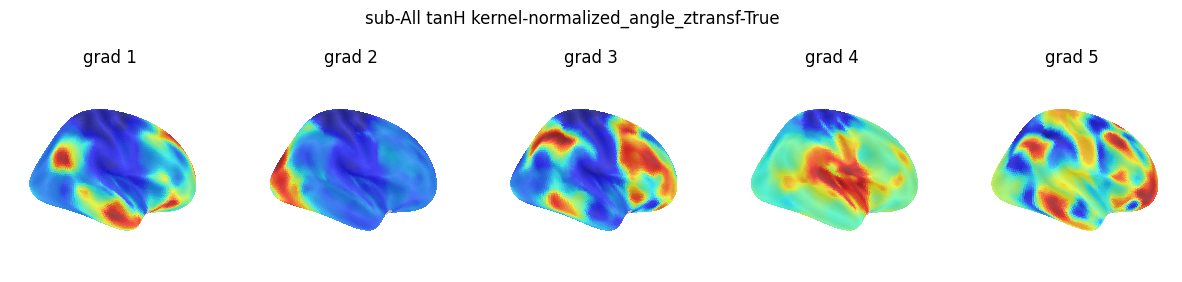

In [3]:
from utils import plot_grads
plot_grads(grad, sub, alignRef, specification)


Text(0.5, 1.0, 'sub-65 Gradient 1 kernel-normalized_angle_ztransf-True')

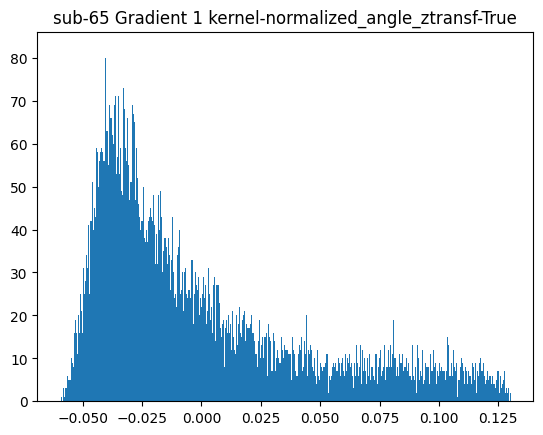

In [47]:
plt.hist(grad[0], bins=1000)
plt.title(f'sub-{sub} Gradient 1 {specification}')

In [6]:
ztransf = False
specification = f'kernel-{kernel}_ztransf-{ztransf}'
 
#fn = op.join(target_dir,f'sub-{sub}_g-aligned-{alignRef}_{specification}.npy')
fn = op.join(target_dir,f'sub-{sub}_gradients_kernel-{kernel}_ztransf-{ztransf}_avMethod-{alignRef}.npy') # sub-All_gradients_kernel-normalized_angle_ztransf-False_avMethod-tanH.npy
grad_noZ = np.load(fn)

In [8]:
grad

array([[-0.063465  , -0.04191326, -0.06017991, ...,  0.0334417 ,
         0.03087784,  0.03524705],
       [-0.04686011,  0.00627767, -0.0459306 , ..., -0.01091218,
        -0.01082616, -0.00802567],
       [-0.03680923,  0.06232854, -0.03181572, ..., -0.00838621,
        -0.00845255, -0.0055844 ],
       ...,
       [ 0.03673403,  0.01330096,  0.02164182, ...,  0.01299045,
         0.01234639,  0.01347442],
       [-0.02362206,  0.00862515, -0.02015092, ...,  0.07249683,
         0.07239239,  0.07146774],
       [ 0.03996734, -0.02337588,  0.0294967 , ...,  0.02746825,
         0.02826469,  0.02955967]])

In [7]:
grad_noZ

array([[-0.06713247, -0.04204552, -0.06290355, ...,  0.03010685,
         0.02798813,  0.03230739],
       [-0.04723993,  0.00780527, -0.04586961, ..., -0.01060598,
        -0.01056816, -0.00799973],
       [-0.03711251,  0.06470924, -0.03170079, ..., -0.00815111,
        -0.00823533, -0.00556009],
       ...,
       [ 0.03851022,  0.01269362,  0.02305445, ...,  0.00737447,
         0.00687752,  0.00799323],
       [-0.02640014,  0.01297057, -0.02347621, ...,  0.06372076,
         0.06402451,  0.06313756],
       [ 0.03709155, -0.02183556,  0.02710521, ...,  0.03546799,
         0.03650917,  0.03763536]])

In [21]:
# standard CA atlas 
from utils import get_fsav5_CAatlas_mapping, get_basic_mask
CAatlas_fsav5 = get_fsav5_CAatlas_mapping()

In [ ]:
# own network atlas
fn_target_labels_caNets = op.join(bids_folder,'derivatives','networks_infomap_full', f'sub-average_consensusMapping_confspec-36Pscrub3BPfilter.npy') # mapped to ColeAnticevic nets
mask, _ = get_basic_mask()
CAatlas_fsav5 = np.zeros(np.shape(mask))
CAatlas_fsav5[mask] = np.load(fn_target_labels_caNets)
atlas_spec = 'own_av_netAtlas'

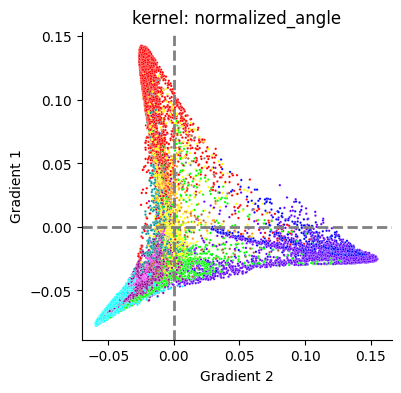

In [22]:
df = pd.DataFrame({'g1': grad[0], 'g2': grad[1], 'g3':grad[2],'ca_network': CAatlas_fsav5})

import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns
rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
ca_cmap = ListedColormap(np.vstack((np.array([[0.5, 0.5, 0.5, 1.0]]), rgb)), 'custom_colormap') # add grey infront, 0=unknown, 1-12 actual labels

fig, axs = plt.subplots(1,1,figsize=(4,4))
sns.scatterplot(df, x='g2', y='g1', hue='ca_network',palette=ca_cmap,s=3, legend=False)#
#axs.set(ylim=(-15,15), xlim=(-7,20))
axs.set(xlabel='Gradient 2', ylabel='Gradient 1')
plt.axhline(0, color='grey', lw=2, ls='--')
plt.axvline(0, color='grey', lw=2, ls='--')
plt.title(f'kernel: {kernel}')
sns.despine()

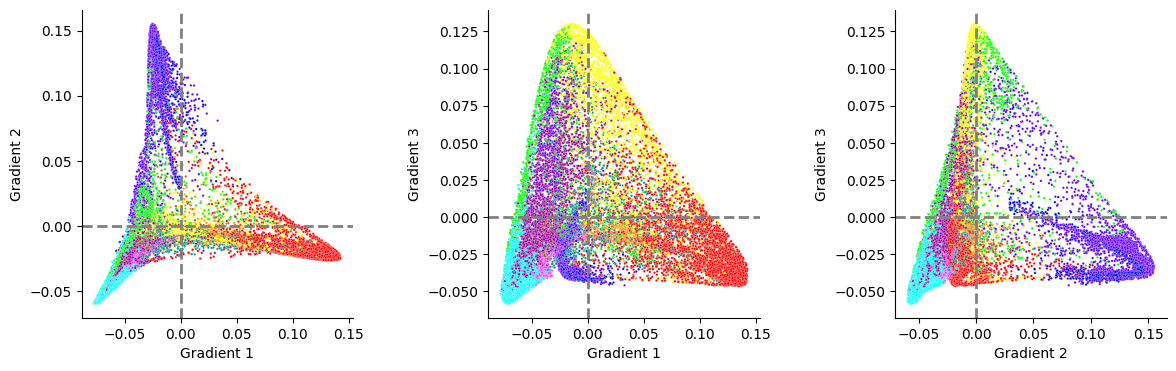

In [23]:
fig, axs = plt.subplots(1,3,figsize=(14,4))

for i,grad_i_s in enumerate([[1,2],[1,3],[2,3]]):
    sns.scatterplot(df, x=f'g{grad_i_s[0]}', y=f'g{grad_i_s[1]}', hue='ca_network',palette=ca_cmap,s=3, legend=False, ax=axs[i])#
    axs[i].set(xlabel=f'Gradient {grad_i_s[0]}', ylabel=f'Gradient {grad_i_s[1]}')
    sns.despine()
    axs[i].axhline(0, color='grey', lw=2, ls='--')
    axs[i].axvline(0, color='grey', lw=2, ls='--')
fig.subplots_adjust(wspace=0.5)


# Prep GM code

### fit gradients dParams

In [2]:
sub = '01'
ses = '1'
task = 'magjudge'
confspec ='36Pscrub3BPfilterrunFD104-6runs'
key = f'.{confspec}'

kernel ='normalized_angle'  # None #'cosine'  #

target_dir = op.join(bids_folder, 'derivatives', f'gradients{key}', f'sub-{sub}')
if not op.exists(target_dir):
    os.makedirs(target_dir)

cm_fn = op.join(bids_folder, 'derivatives', 'correlation_matrices.tryNoHalo', f'sub-{sub}_ses-{ses}_task-magjudge_confspec-{confspec}_CM-unfiltered.npy')
cm = np.load(cm_fn)

In [ ]:
if kernel == None:
    print('Applying CC-mask for kernel=None')
    cm_confspec = f'36Pscrub3BPfilterrunFD104'
    cc_mask_file = op.join(op.join(bids_folder, 'derivatives', f'gradients.{cm_confspec}', f'sub-{sub}'), f'sub-{sub}_cc-mask_space-fsaverag5.npy')
    mask_cc = np.load(cc_mask_file)
    mask[mask == True] = mask_cc
    cm = cm[mask_cc, :][:, mask_cc]

Applying CC-mask for kernel=None


In [9]:
alignRef = '-tanH'

ref_grad = op.join(bids_folder, 'derivatives', f'gradients.tryParams.36P','sub-All', f'sub-All_gradients_kernel-{kernel}_ztransf-False_avMethod-tanH.npy')
grad_ref = np.load(ref_grad)
grad_ref_fil = grad_ref[:,mask].T  # only use nodes in mask

In [ ]:
ztransf = True
cm_ztransf = np.arctanh(cm)
cm_ztransf[np.isnan(cm_ztransf)] = 0 # set nans to zero !


/tmp/ipykernel_1559834/2553686703.py:2: RuntimeWarning: divide by zero encountered in arctanh
  cm_ztransf = np.arctanh(cm)


In [ ]:
n_components = 10
gm = GradientMaps(n_components=n_components, alignment='procrustes', kernel=kernel, approach='dm', random_state=0) 
gm.fit(cm_ztransf,reference=grad_ref_fil)

## Average

In [2]:
# load in average CM and reference gradients
transform_spec = 'tan-hyperbolic' #'_FisherZ' #
confspec= '36Pscrub3BPfilterrunFD104' 
source_folder = op.join(bids_folder,'derivatives','correlation_matrices.tryNoHalo')

av_cm_transf = np.load(op.join(source_folder,f'cm_av_ses-1_fsav5_unfiltered_confspec-{confspec}{transform_spec}.npy'))

bids_folder_ref = f'/mnt_03/ds-dnumrisk'
g_ref = np.load(op.join(bids_folder_ref,'derivatives', 'gradients','reference_gradients_margulies16_space-fsaverage5_N-10.npy'))
from utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
g_ref_fil = g_ref[:,mask].T  # np.shape(g_ref) = (10,20484)

In [3]:
np.isnan(av_cm_transf).sum()

0

In [9]:
cm = np.arctanh(av_cm_transf) 
cm[np.isinf(cm)] = np.nan


/tmp/ipykernel_2131140/3524824878.py:1: RuntimeWarning: divide by zero encountered in arctanh
  cm = np.arctanh(av_cm_transf)


(array([1.2400000e+02, 6.2600000e+02, 3.0400000e+03, 1.0862000e+04,
        2.8186000e+04, 6.5178000e+04, 1.3915400e+05, 2.8659200e+05,
        5.7467800e+05, 1.1379120e+06, 2.2944700e+06, 4.6562860e+06,
        9.5307460e+06, 1.9242960e+07, 3.5394748e+07, 5.5214138e+07,
        6.3399710e+07, 4.8690588e+07, 3.1198816e+07, 2.0995984e+07,
        1.4891682e+07, 1.0765856e+07, 7.9040000e+06, 5.8549100e+06,
        4.3688680e+06, 3.2724020e+06, 2.4570880e+06, 1.8361900e+06,
        1.3711880e+06, 1.0239180e+06, 7.6945000e+05, 5.8245800e+05,
        4.4554400e+05, 3.4137800e+05, 2.6349600e+05, 2.0588200e+05,
        1.6314000e+05, 1.3000600e+05, 1.0675200e+05, 8.7326000e+04,
        7.2654000e+04, 6.0378000e+04, 5.0822000e+04, 4.2552000e+04,
        3.6380000e+04, 2.9824000e+04, 2.5272000e+04, 2.1464000e+04,
        1.7924000e+04, 1.5290000e+04, 1.3286000e+04, 1.1934000e+04,
        1.0838000e+04, 9.5500000e+03, 8.8620000e+03, 8.4480000e+03,
        7.6720000e+03, 7.3480000e+03, 7.3120000e

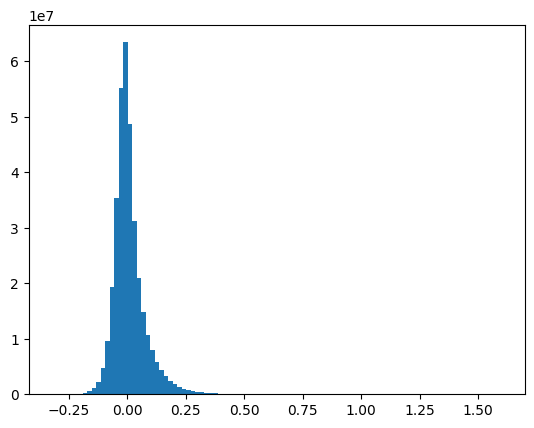

In [10]:
plt.hist(cm.flatten(), bins=100)

In [ ]:
# fit gradients for average CM & save 
sub = 'All'
target_dir = op.join(bids_folder,'derivatives','gradients.tryParams.36P', f'sub-{sub}')
os.makedirs(target_dir, exist_ok=True)

kernel = 'normalized_angle'  # with cosine kernel needs > 60 mins!  None #'cosine'  # None #
ztransf = True
avMethod = 'tanH'

if ztransf:
    cm = np.arctanh(av_cm_transf) 
    cm[np.isinf(cm)] = 0 # set diagonal elements to zero
    print('Z-transformation applied!')
else:
    cm = av_cm_transf
    print('No z-transformation applied!')

# fit gradients
import time
start_time = time.time()
gm = GradientMaps(n_components=10, alignment='procrustes', kernel=kernel, approach='dm', random_state=0)
gm.fit(cm, reference=g_ref_fil)
elapsed_time = time.time() - start_time
print(f"GM fitting Execution time: {elapsed_time/60:.2f} minutes ({elapsed_time:.2f} seconds)")

# save
specification = f'kernel-{kernel}_ztransf-{ztransf}_avMethod-{avMethod}'
np.save(op.join(target_dir,f'sub-{sub}_lambdas_{specification}.npy'), gm.lambdas_) # save all together
gm_= gm.gradients_.T 
grad = [None] * 10
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_gradients_{specification}.npy'), grad) # save all together
gm_ = gm.aligned_.T
grad = [None] * 10
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_g-aligned-marg_{specification}.npy'), grad) # save all together
print(f'Gradient files saved {op.join(target_dir,f'sub-{sub}_gradients_{specification}.npy')}!')